# grid_py Tutorial 3: CairoRenderer vs WebRenderer Side-by-Side

This notebook draws the **same scene** with both backends to verify:
1. The API is identical (same code, swap one line)
2. The visual output matches
3. WebRenderer adds interactivity that Cairo cannot

In [1]:
import numpy as np
from IPython.display import display, Image, HTML

from grid_py import (
    CairoRenderer, WebRenderer, Gpar, Unit,
    Viewport, GridLayout,
    get_state, grid_draw,
    push_viewport, pop_viewport,
    rect_grob, circle_grob, text_grob,
    points_grob, lines_grob, segments_grob, polygon_grob,
)

## The Scene

Define a function that draws a complete scene using **only the grid_py API** — no renderer-specific code.

In [2]:
def draw_demo_scene(renderer):
    """Draw a demo scene using any GridRenderer subclass."""
    state = get_state()
    state.init_device(renderer)

    # Background
    grid_draw(rect_grob(x=0.5, y=0.5, width=1.0, height=1.0,
                         gp=Gpar(fill='#fafbfc', col='#d0d7de')))

    # Title
    grid_draw(text_grob(
        label=f'Rendered by {type(renderer).__name__}',
        x=0.5, y=0.96,
        gp=Gpar(fontsize=14, fontface='bold', col='#24292f')))

    # Create plot area with layout
    layout = GridLayout(nrow=1, ncol=2,
                         widths=Unit([1, 1], 'null'),
                         heights=Unit([1], 'null'))
    main_vp = Viewport(name='main', x=0.5, y=0.46, width=0.92, height=0.82,
                        layout=layout)
    push_viewport(main_vp, recording=False)
    renderer.push_viewport(main_vp)

    # --- Left panel: scatter ---
    left_vp = Viewport(name='scatter', layout_pos_row=1, layout_pos_col=1)
    push_viewport(left_vp, recording=False)
    renderer.push_viewport(left_vp)

    grid_draw(rect_grob(x=0.5, y=0.5, width=0.93, height=0.93,
                         gp=Gpar(fill='white', col='#d0d7de')))

    np.random.seed(123)
    n = 40
    sx = np.random.rand(n) * 0.75 + 0.12
    sy = np.random.rand(n) * 0.65 + 0.15
    groups = np.random.choice(['A', 'B', 'C'], n)
    cmap = {'A': '#e63946', 'B': '#457b9d', 'C': '#2a9d8f'}
    sc = [cmap[g] for g in groups]

    grob = points_grob(x=sx.tolist(), y=sy.tolist(), pch=19,
                        gp=Gpar(col=sc, fill=sc, fontsize=5, alpha=0.7))
    grob.metadata = {
        'group': groups.tolist(),
        'x': [f'{v:.2f}' for v in sx],
        'y': [f'{v:.2f}' for v in sy],
    }
    grid_draw(grob)

    grid_draw(text_grob(label='Scatter Plot', x=0.5, y=0.93,
                         gp=Gpar(fontsize=10, fontface='bold', col='#24292f')))

    pop_viewport(1, recording=False)
    renderer.pop_viewport()

    # --- Right panel: bar chart ---
    right_vp = Viewport(name='bars', layout_pos_row=1, layout_pos_col=2)
    push_viewport(right_vp, recording=False)
    renderer.push_viewport(right_vp)

    grid_draw(rect_grob(x=0.5, y=0.5, width=0.93, height=0.93,
                         gp=Gpar(fill='white', col='#d0d7de')))

    bar_vals = [0.6, 0.85, 0.45, 0.7, 0.55]
    bar_colors = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#264653']
    bar_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
    bar_w = 0.12

    for i, (val, color, label) in enumerate(zip(bar_vals, bar_colors, bar_labels)):
        bx = 0.15 + i * 0.17
        by = 0.12 + val * 0.7 / 2
        bh = val * 0.7
        grid_draw(rect_grob(x=bx, y=by, width=bar_w, height=bh,
                             gp=Gpar(fill=color, col='white', lwd=1)))
        grid_draw(text_grob(label=label, x=bx, y=0.07,
                             gp=Gpar(fontsize=8, col='#57606a')))
        grid_draw(text_grob(label=f'{val:.0%}', x=bx, y=by + bh/2 + 0.04,
                             gp=Gpar(fontsize=7, col=color)))

    # Baseline
    grid_draw(segments_grob(
        x0=[0.07], y0=[0.12], x1=[0.95], y1=[0.12],
        gp=Gpar(col='#d0d7de', lwd=1)))

    grid_draw(text_grob(label='Weekly Summary', x=0.5, y=0.93,
                         gp=Gpar(fontsize=10, fontface='bold', col='#24292f')))

    pop_viewport(1, recording=False)
    renderer.pop_viewport()

    pop_viewport(1, recording=False)
    renderer.pop_viewport()

    return renderer

## CairoRenderer Output (static PNG)

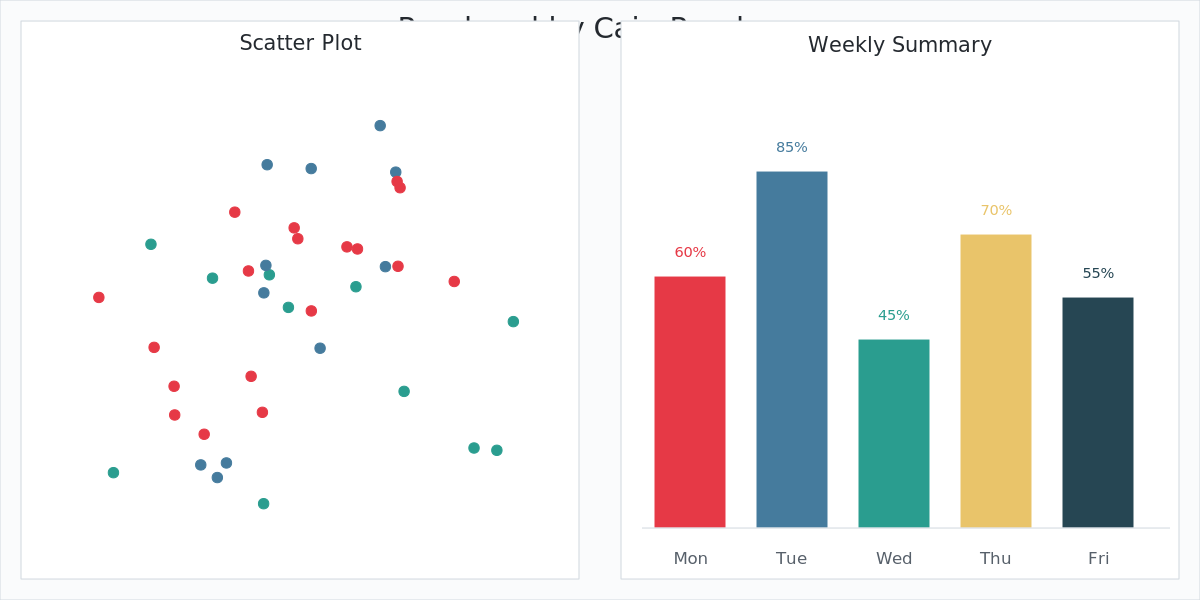

In [3]:
cairo_r = draw_demo_scene(CairoRenderer(width=8, height=4, dpi=150))
display(Image(data=cairo_r.to_png_bytes()))

## WebRenderer Output (interactive HTML)

**Same code, different renderer.** Try:
- Hover over scatter points to see group/coordinate data
- Scroll to zoom, drag to pan
- The bar chart elements are also interactive

In [4]:
web_r = draw_demo_scene(WebRenderer(width=8, height=4, dpi=100))
display(HTML(web_r.to_html()))

## Compare Scene Graph Structure

In [5]:
import json

sg = json.loads(web_r.to_scene_json())

def count_nodes(node):
    total = 1
    for child in node.get('children', []):
        total += count_nodes(child)
    return total

def count_by_type(node, counts=None):
    if counts is None:
        counts = {}
    t = node.get('type', '?')
    counts[t] = counts.get(t, 0) + 1
    for child in node.get('children', []):
        count_by_type(child, counts)
    return counts

print(f'Total scene graph nodes: {count_nodes(sg["root"])}')
print(f'Defs: {len(sg["defs"]["gradients"])} gradients, '
      f'{len(sg["defs"]["clip_paths"])} clips')
print()
print('Node type counts:')
for t, c in sorted(count_by_type(sg['root']).items(), key=lambda x: -x[1]):
    print(f'  {t:12s}: {c}')

Total scene graph nodes: 27
Defs: 0 gradients, 0 clips

Node type counts:
  text        : 13
  rect        : 8
  viewport    : 4
  points      : 1
  segments    : 1


## Save Both Outputs

In [6]:
cairo_r.write_to_png('comparison_cairo.png')
web_r.save('comparison_web.html')

print('Saved comparison_cairo.png (static)')
print('Saved comparison_web.html (interactive — open in browser)')
print(f'\nPNG size: {len(cairo_r.to_png_bytes()) / 1024:.1f} KB')
print(f'HTML size: {len(web_r.to_html()) / 1024:.1f} KB')

Saved comparison_cairo.png (static)
Saved comparison_web.html (interactive — open in browser)

PNG size: 28.7 KB
HTML size: 38.8 KB
